In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf

In [2]:
df = pd.read_csv('database/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


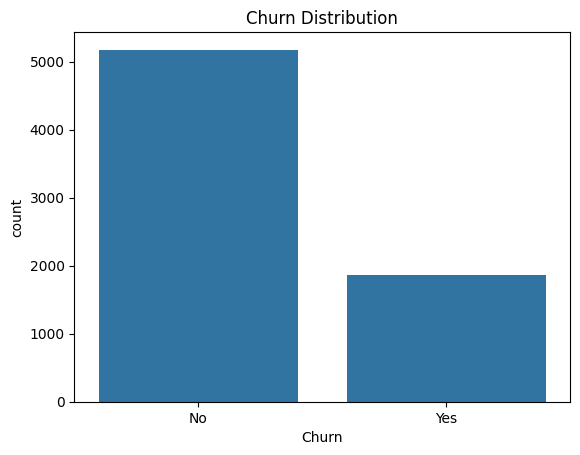

In [4]:
sb.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

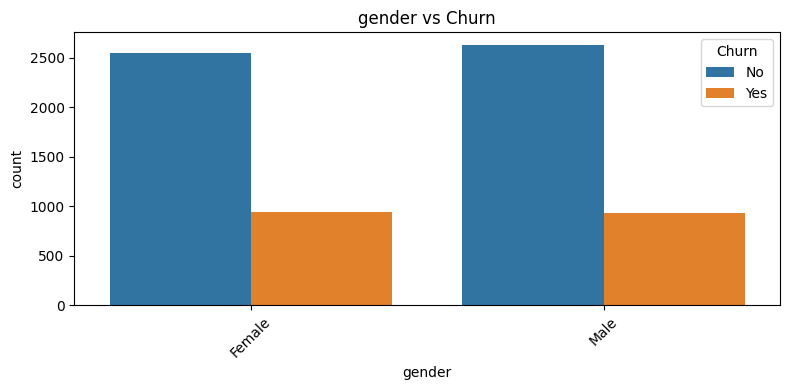

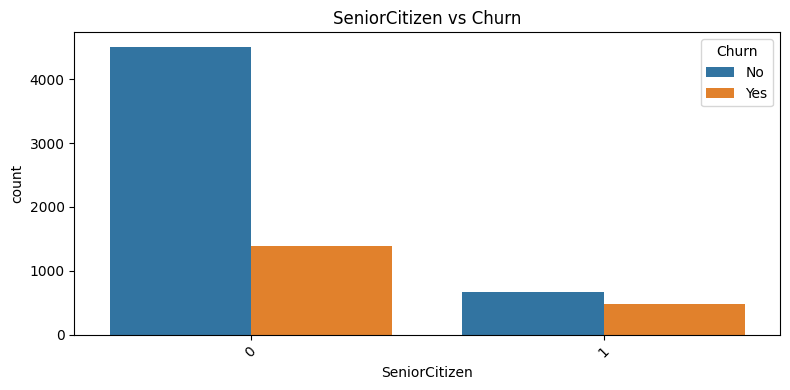

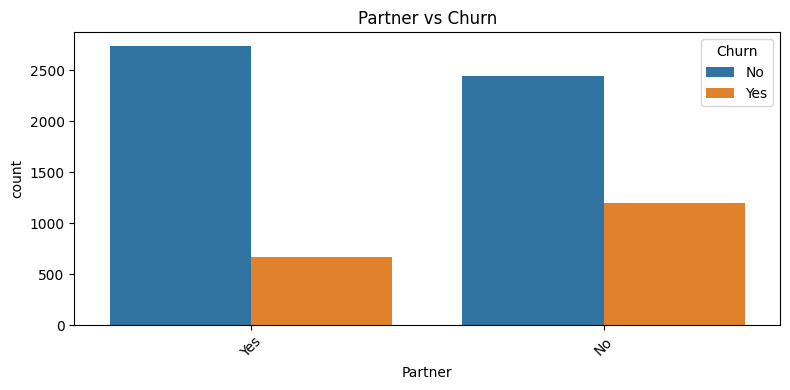

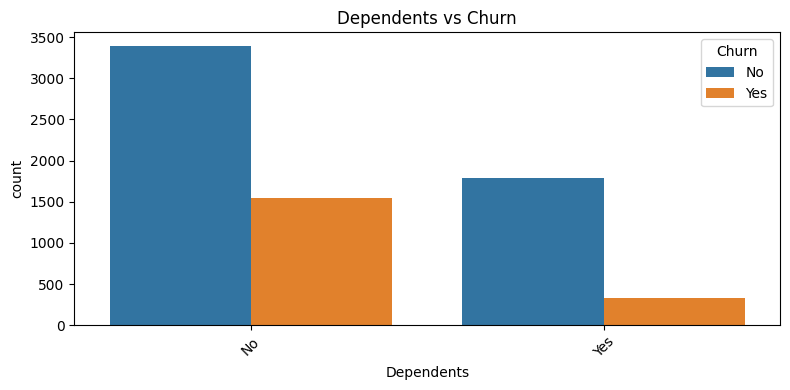

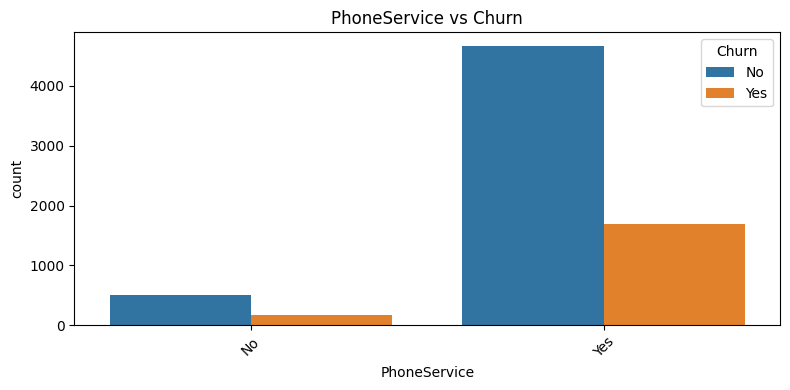

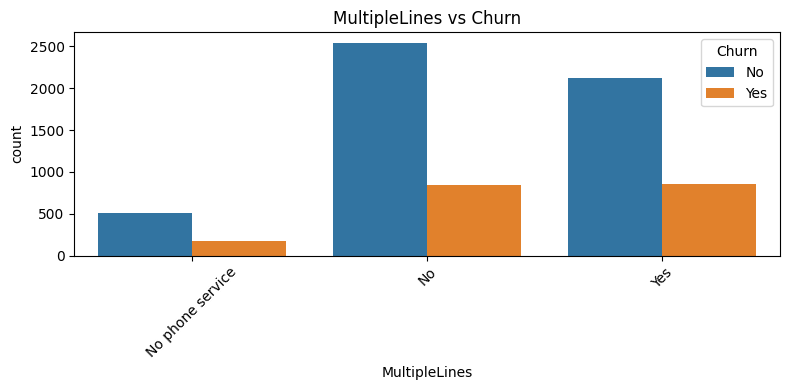

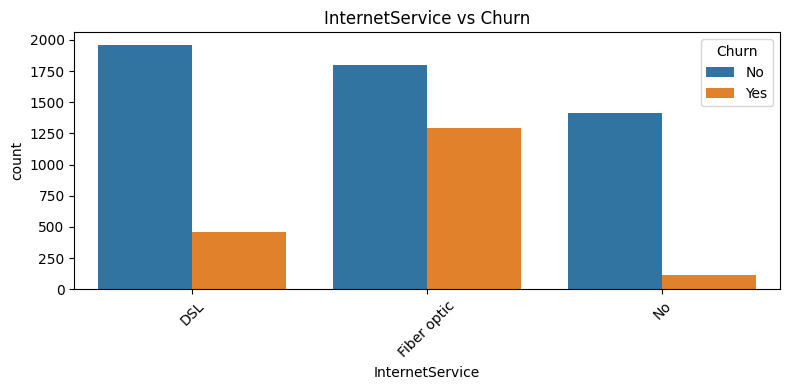

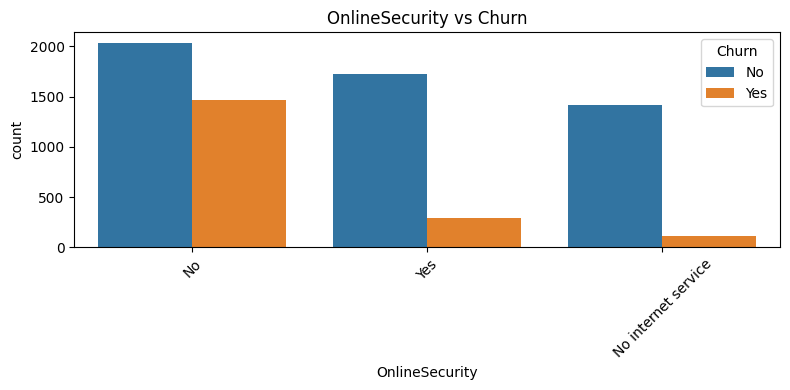

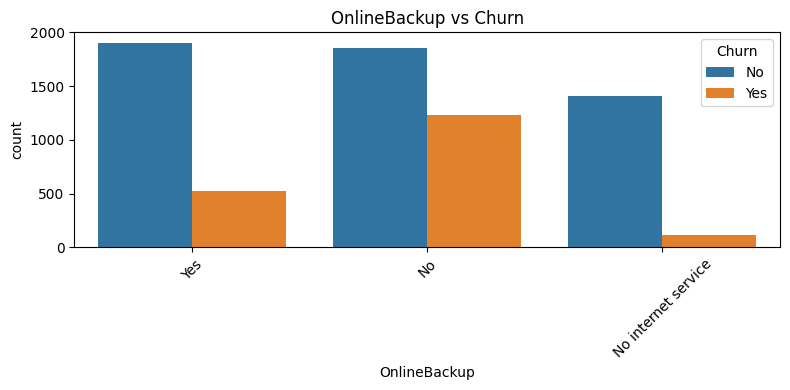

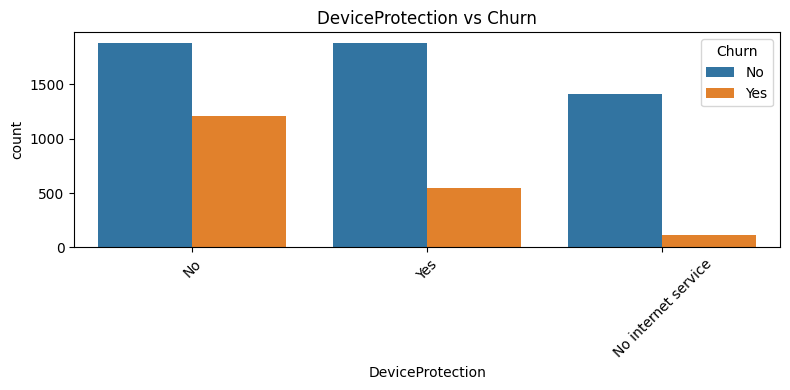

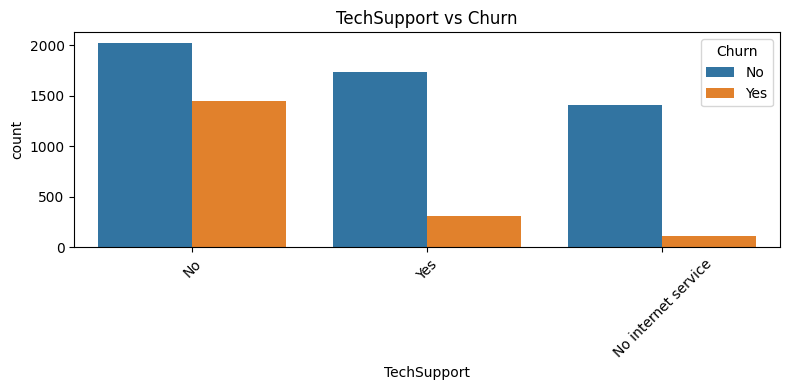

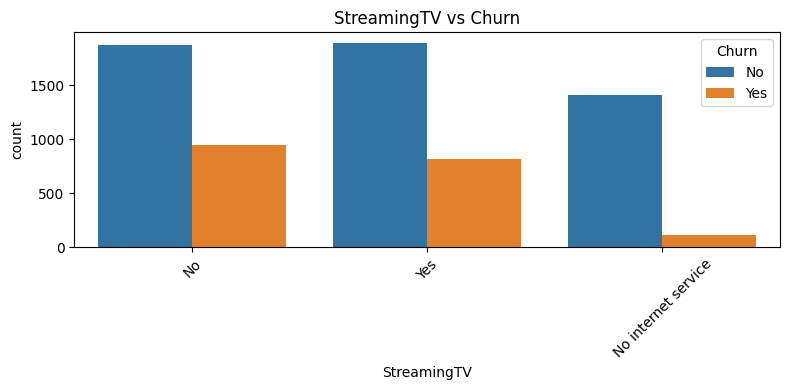

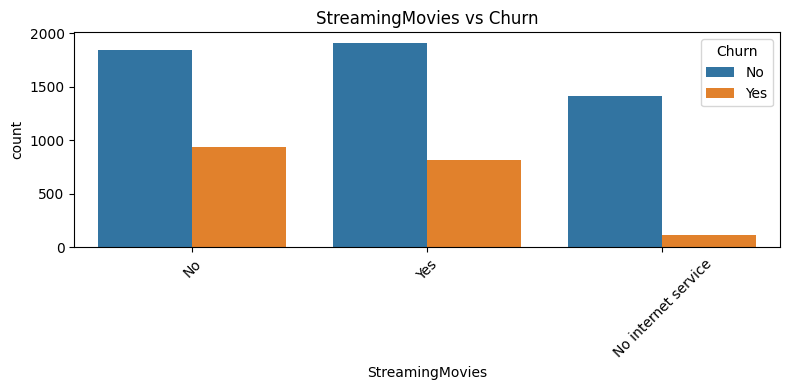

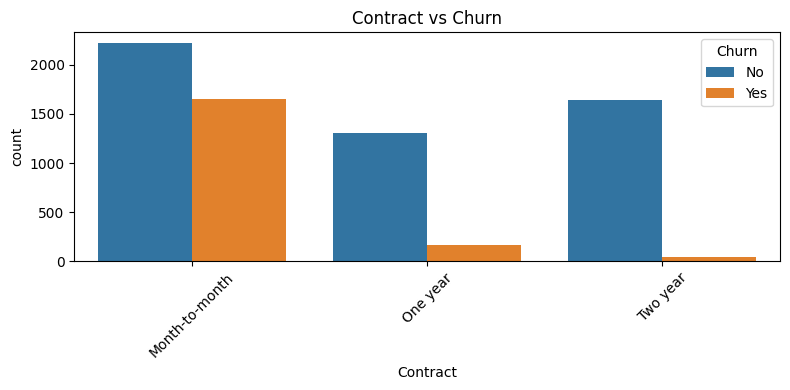

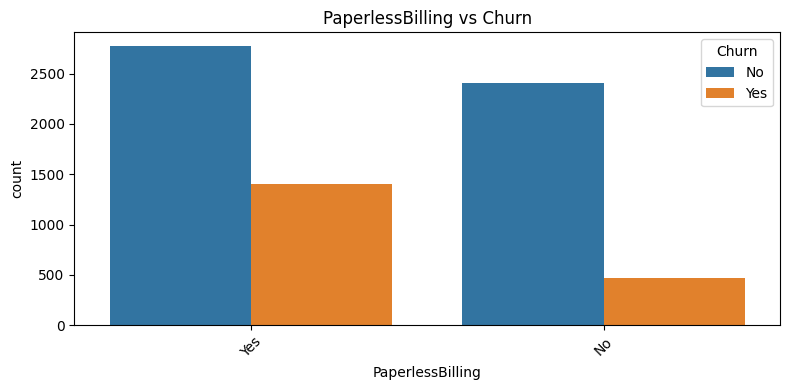

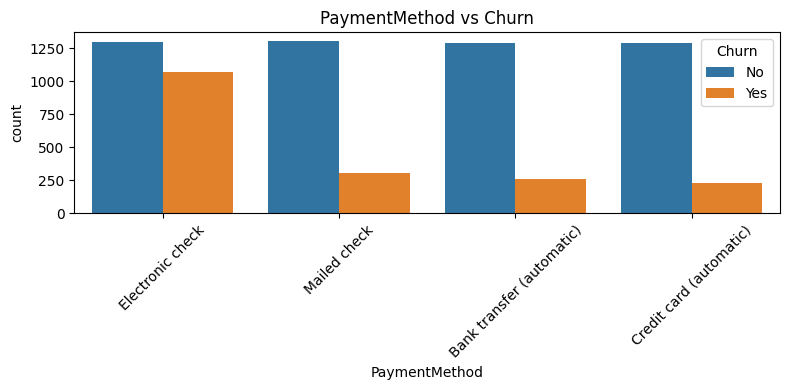

In [5]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                    'PhoneService', 'MultipleLines', 'InternetService',
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod']

for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sb.countplot(data=df, x=col, hue='Churn')
    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


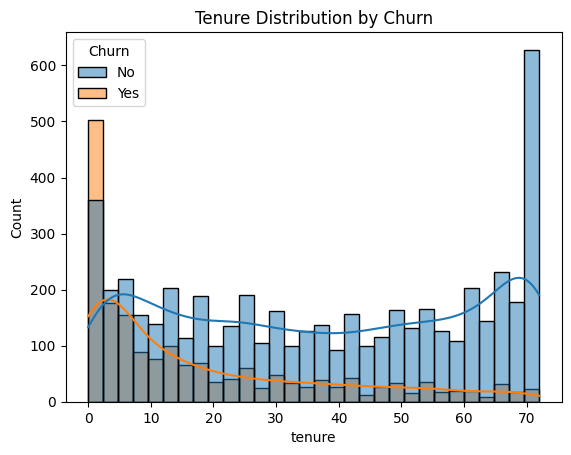

In [6]:
sb.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30)
plt.title('Tenure Distribution by Churn')
plt.show()

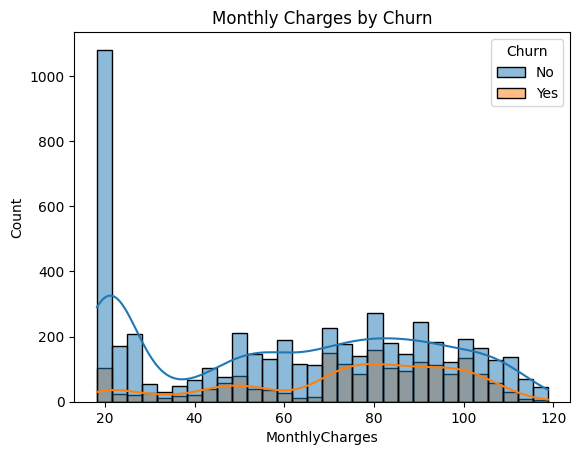

In [7]:
sb.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, bins=30)
plt.title('Monthly Charges by Churn')
plt.show()

In [8]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
    
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [9]:
internet_related = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_related:
    df[col] = df[col].replace({'No internet service': 'No'})

for col in internet_related:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
    
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [10]:
df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})
df['MultipleLines'] = df['MultipleLines'].map({'Yes': 1, 'No': 0})

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,0,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,1,0,0,0,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,0,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,1,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,0,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1


In [11]:
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,Female,0,1,0,1,0,0,0,1,...,29.85,29.85,0,False,False,False,False,False,True,False
1,5575-GNVDE,Male,0,0,0,34,1,0,1,0,...,56.95,1889.5,0,False,False,True,False,False,False,True
2,3668-QPYBK,Male,0,0,0,2,1,0,1,1,...,53.85,108.15,1,False,False,False,False,False,False,True
3,7795-CFOCW,Male,0,0,0,45,0,0,1,0,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,9237-HQITU,Female,0,0,0,2,1,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [12]:
df.drop(columns=['customerID', 'gender'], inplace=True)
df.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,0,0,1,0,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,0,0,0,34,1,0,1,0,1,0,...,56.95,1889.5,0,False,False,True,False,False,False,True
2,0,0,0,2,1,0,1,1,0,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,0,0,0,45,0,0,1,0,1,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,2,1,0,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].replace(" ", pd.NA), errors='coerce')
print(df['TotalCharges'].isna().sum())
df.dropna(subset=['TotalCharges'], inplace=True)

11


In [14]:
df = df.astype({col: 'int' for col in df.select_dtypes(include='bool').columns})


In [15]:
df.dtypes

SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                int64
InternetService_No                         int64
Contract_One year                          int64
Contract_Two year                          int64
PaymentMethod_Credit

In [16]:
X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()

models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000),
        'params': {
            'model__C': [0.01, 0.1, 1, 10],
            'model__penalty': ['l2']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'model__max_depth': [3, 5, 10, None],
            'model__criterion': ['gini', 'entropy']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'model__n_estimators': [50, 100],
            'model__max_depth': [5, 10, None]
        }
    },
    'SVM': {
        'model': SVC(probability=True),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'model__n_neighbors': [3, 5, 11]
        }
    },
    'NaiveBayes': {
        'model': GaussianNB(),
        'params': {}
    }
}

results = []

for name, config in models.items():
    print(f"Running: {name}")
    
    pipe = Pipeline([
        ('scaler', scaler),
        ('model', config['model'])
    ])

    clf = GridSearchCV(pipe, config['params'], cv=5, scoring='accuracy')
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else None
    
    results.append({
        'Model': name,
        'Best Params': clf.best_params_,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1 Score', ascending=False)
print(results_df)


Running: LogisticRegression
Running: DecisionTree
Running: RandomForest
Running: SVM
Running: KNN
Running: NaiveBayes
                Model                                        Best Params  \
0  LogisticRegression          {'model__C': 0.1, 'model__penalty': 'l2'}   
5          NaiveBayes                                                 {}   
3                 SVM       {'model__C': 0.1, 'model__kernel': 'linear'}   
2        RandomForest  {'model__max_depth': 10, 'model__n_estimators'...   
4                 KNN                         {'model__n_neighbors': 11}   
1        DecisionTree  {'model__criterion': 'gini', 'model__max_depth...   

   Accuracy  Precision    Recall  F1 Score   ROC AUC  
0  0.803127   0.646526  0.572193  0.607092  0.835112  
5  0.736318   0.502683  0.751337  0.602358  0.821906  
3  0.797441   0.636923  0.553476  0.592275  0.828025  
2  0.799574   0.657534  0.513369  0.576577  0.832189  
4  0.764748   0.557641  0.556150  0.556894  0.792061  
1  0.784648   0.656

In [17]:
def plot_history(histories):
    for name, history in histories:
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']
        epochs = range(1, len(acc) + 1)

        plt.figure(figsize=(14, 5))

        plt.subplot(1, 2, 1)
        plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
        plt.plot(epochs, val_acc, 'go-', label='Validation Accuracy')
        plt.title(f'Accuracy: {name}')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend()
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.plot(epochs, loss, 'bo-', label='Training Loss')
        plt.plot(epochs, val_loss, 'go-', label='Validation Loss')
        plt.title(f'Loss: {name}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid()

        plt.tight_layout()
        plt.show()

Training model: 2 layers (32,16), relu, dropout
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


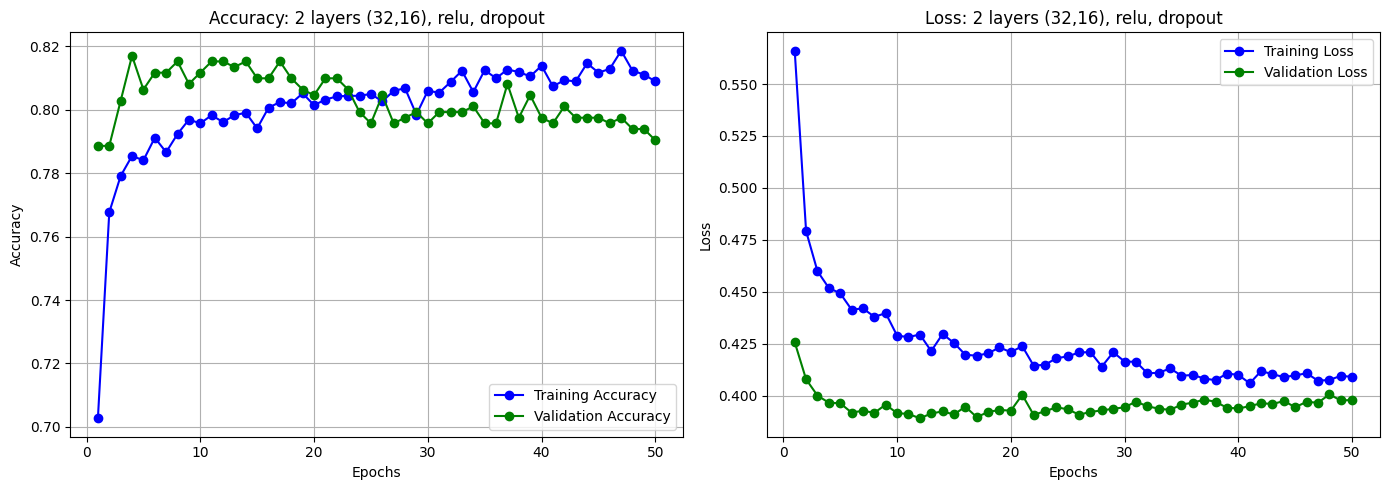

Training model: 3 layers (64,32,16), relu, dropout
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


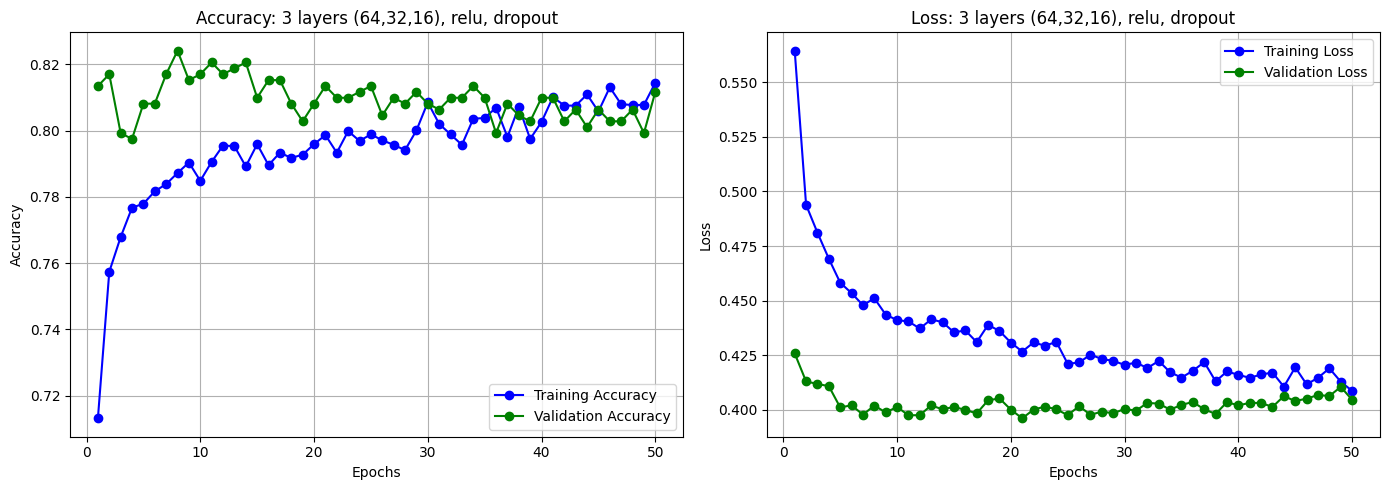

Training model: 2 layers (64,32), tanh, low dropout
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


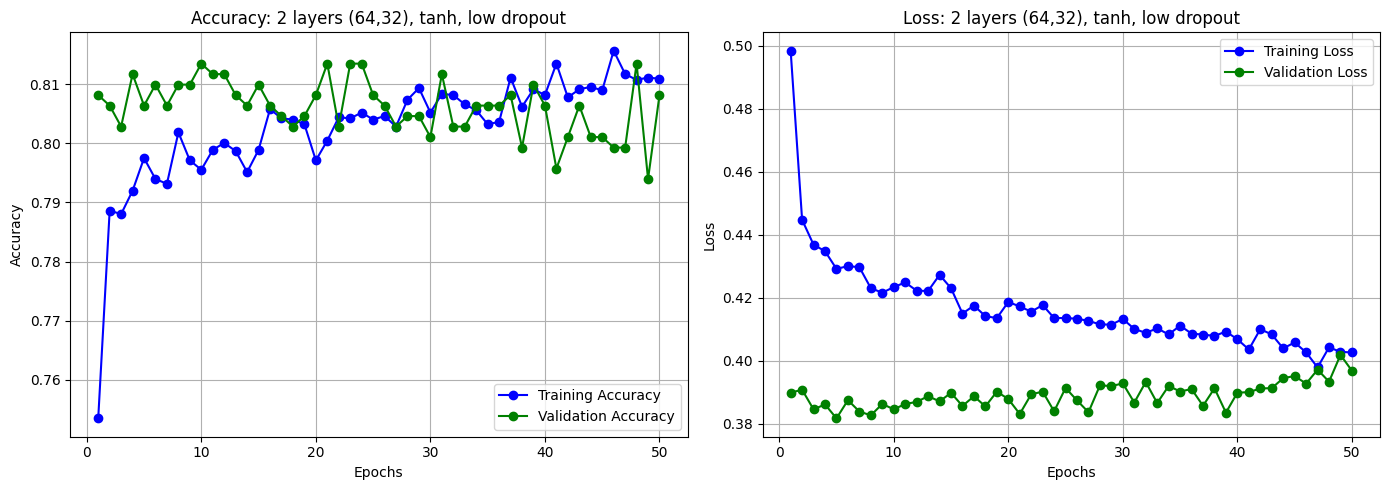

Training model: 2 layers (128,64), relu, sgd
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


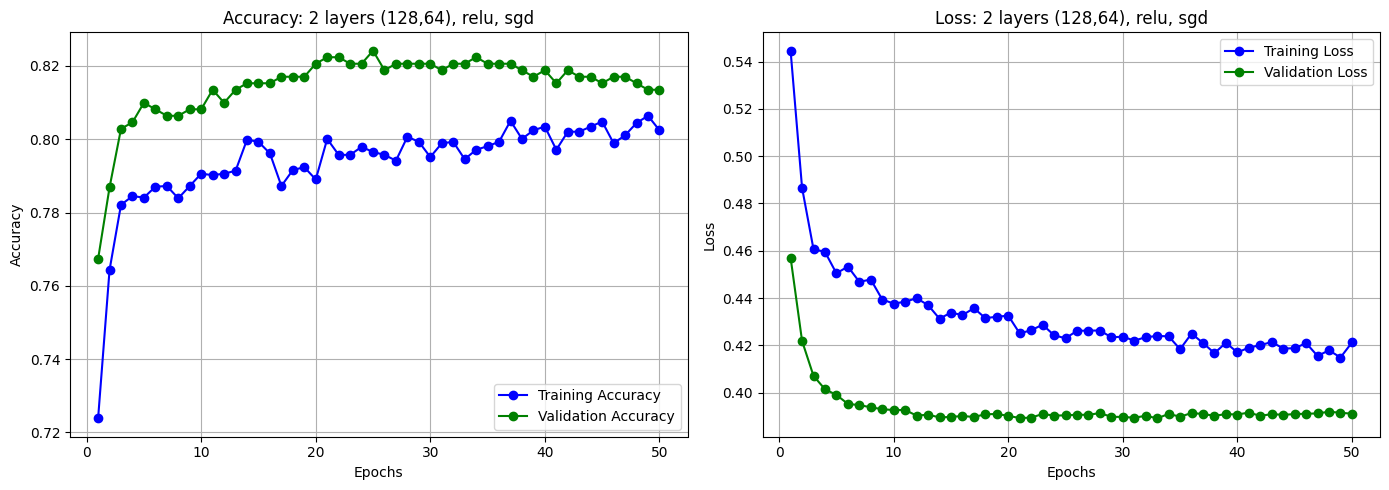

                                 Model  Accuracy  Precision    Recall  \
3         2 layers (128,64), relu, sgd  0.796731   0.632530  0.561497   
1   3 layers (64,32,16), relu, dropout  0.799574   0.644654  0.548128   
2  2 layers (64,32), tanh, low dropout  0.788913   0.638989  0.473262   
0      2 layers (32,16), relu, dropout  0.785359   0.631387  0.462567   

   F1 Score   ROC AUC  
3  0.594901  0.834191  
1  0.592486  0.833317  
2  0.543779  0.833337  
0  0.533951  0.827758  


In [18]:
X = df.drop('Churn', axis=1).values
y = df['Churn'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

configs = [
    {
        'name': '2 layers (32,16), relu, dropout',
        'layers': [32, 16],
        'activation': 'relu',
        'dropout': 0.3,
        'optimizer': 'adam',
        'epochs': 50,
        'batch_size': 32
    },
    {
        'name': '3 layers (64,32,16), relu, dropout',
        'layers': [64, 32, 16],
        'activation': 'relu',
        'dropout': 0.4,
        'optimizer': 'adam',
        'epochs': 50,
        'batch_size': 32
    },
    {
        'name': '2 layers (64,32), tanh, low dropout',
        'layers': [64, 32],
        'activation': 'tanh',
        'dropout': 0.2,
        'optimizer': 'adam',
        'epochs': 50,
        'batch_size': 32
    },
    {
        'name': '2 layers (128,64), relu, sgd',
        'layers': [128, 64],
        'activation': 'relu',
        'dropout': 0.3,
        'optimizer': 'sgd',
        'epochs': 50,
        'batch_size': 32
    },
]

results = []

for config in configs:
    print(f"Training model: {config['name']}")
    
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(X_train.shape[1],)))

    for units in config['layers']:
        model.add(tf.keras.layers.Dense(units, activation=config['activation']))
        model.add(tf.keras.layers.Dropout(config['dropout']))
    
    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    model.compile(optimizer=config['optimizer'], loss='binary_crossentropy', metrics=['accuracy'])

    histories = []

    history = model.fit(
    X_train, y_train,
    epochs=config['epochs'],
    batch_size=config['batch_size'],
    validation_split=0.1,
    verbose=0
    )

    histories.append((config['name'], history))


    y_pred_probs = model.predict(X_test).flatten()
    y_pred = (y_pred_probs > 0.5).astype(int)

    results.append({
        'Model': config['name'],
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_pred_probs)
    })
    plot_history(histories)


results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1 Score', ascending=False)
print(results_df)
